# 04 · X-ray 검사장비 데이터 탐색

## EDA 계획

1. 전체 파일을 조사하고 이미지 디코딩으로 실제 이미지/비이미지 파일을 구분합니다.
2. 도구 예제 XML을 분리하고 X-ray 이름 패턴, 이미지·주석 매칭, 중복을 점검합니다.
3. 해상도·밝기·대비, 결함 개수와 박스 크기·위치를 시각화합니다.
4. 실제 이미지 위에 박스를 표시하고 VOC/YOLO 주석의 대응을 검증합니다.
5. 기존 train/test 목록의 파일 존재·중복을 확인하고 학습 가능 규모를 판단합니다.


원본 데이터는 수정하지 않습니다. 위에서부터 실행하세요. 프로젝트 `.venv` 커널과 `notebooks/requirements.txt`의 패키지를 사용합니다. 수치와 도표는 전체 데이터를 기준으로 하며 표본·표시 범위를 제한하면 해당 셀에 명시합니다. 탐색 결과는 모델 성능이나 인과 효과를 의미하지 않습니다.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
from IPython.display import display
SEED = 42
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'data').is_dir())
pd.set_option('display.max_columns', 30)
fonts = {f.name for f in font_manager.fontManager.ttflist}
plt.rcParams['font.family'] = [next((f for f in ['Malgun Gothic','AppleGothic','NanumGothic'] if f in fonts), 'DejaVu Sans'), 'DejaVu Sans']
plt.rcParams.update({'axes.unicode_minus':False, 'figure.dpi':110, 'axes.spines.top':False, 'axes.spines.right':False})

def quality(df, exclude=()):
    x = df.drop(columns=list(exclude), errors='ignore')
    out = pd.DataFrame({'dtype':x.dtypes.astype(str), 'missing':x.isna().sum(),
                        'missing_pct':x.isna().mean()*100, 'unique':x.nunique()})
    print(f'행 {len(df):,} / 열 {len(df.columns)} / 제외 열을 뺀 중복 {x.duplicated().sum():,}')
    display(out)
    return out

def corr_plot(df, cols, title):
    corr = df[cols].corr(method='spearman')
    fig, ax = plt.subplots(figsize=(max(7,len(cols)*.65), max(5,len(cols)*.6)))
    im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
    ax.set_xticks(range(len(cols)),cols,rotation=70,ha='right')
    ax.set_yticks(range(len(cols)),cols); ax.set_title(title)
    fig.colorbar(im, ax=ax); plt.tight_layout(); plt.show()

def hist_grid(df, cols, title):
    fig, axes = plt.subplots(int(np.ceil(len(cols)/3)),3,figsize=(15,3.4*int(np.ceil(len(cols)/3))),squeeze=False)
    for ax,c in zip(axes.flat,cols):
        ax.hist(df[c].replace([np.inf,-np.inf],np.nan).dropna(),bins=40,color='#2563eb',alpha=.8)
        ax.set_title(c,fontsize=10); ax.set_ylabel('행 수')
    for ax in list(axes.flat)[len(cols):]: ax.set_visible(False)
    fig.suptitle(title); plt.tight_layout(); plt.show()

DATA = next((ROOT / 'data').glob('4.*'))

## 1. 파일 실체와 분석 범위
확장자만으로 이미지라고 판단하지 않습니다. X-ray 원본 후보는 `001_` 또는 `002_`로 시작하는 시각 형식 파일명입니다. 이 규칙으로 도구 예제·결과 이미지를 제외하되, 목록과 제외 수를 표시합니다. 포함된 학습 코드나 노트북은 실행하지 않습니다.

In [2]:
import re, hashlib
import xml.etree.ElementTree as ET
from PIL import Image, UnidentifiedImageError
from matplotlib.patches import Rectangle
files=sorted(p for p in DATA.rglob('*') if p.is_file())
display(pd.Series([p.suffix or '(없음)' for p in files]).value_counts().rename('files').to_frame())
pattern=re.compile(r'^(001|002)_\d{8}_\d{6}\(\d+\)$')
image_rows=[]; unreadable=[]
for p in files:
    if p.suffix.lower() not in ['.jpg','.jpeg','.png','.bmp']:continue
    try:
        with Image.open(p) as im:
            im.load(); arr=np.asarray(im.convert('L'))
            image_rows.append({'path':p,'stem':p.stem,'width':im.width,'height':im.height,'format':im.format,
                               'mean':arr.mean(),'std':arr.std(),'candidate':bool(pattern.match(p.stem)),
                               'pixel_hash':hashlib.sha256(str(im.size).encode()+im.convert('RGB').tobytes()).hexdigest()})
    except (UnidentifiedImageError,OSError) as e:
        unreadable.append({'path':str(p.relative_to(DATA)),'reason':type(e).__name__})
images=pd.DataFrame(image_rows);candidates=images[images.candidate].copy()
unique_images=candidates.drop_duplicates('pixel_hash').copy()
display(pd.DataFrame(unreadable))
print('이미지 확장자:',len(images)+len(unreadable),'디코딩 성공:',len(images),'X-ray 후보 파일:',len(candidates),'픽셀 중복 제거:',len(unique_images))
display(candidates[['stem','format','width','height','pixel_hash']])
display(images.loc[~images.candidate,['path','format']])

,files
.xml,833
.txt,21
.jpg,19
.bmp,15
.py,10
(없음),6
.jpgpes,2
.shapes,2
.ipynb,2
.ini,1


,path,reason
0,4. X-ray 검사장비 AI 데이터셋\dataset\test1\yolov3\det...,UnidentifiedImageError
1,4. X-ray 검사장비 AI 데이터셋\dataset\test1\yolov3\Doc...,UnidentifiedImageError
2,4. X-ray 검사장비 AI 데이터셋\dataset\test1\yolov3\img...,UnidentifiedImageError
3,4. X-ray 검사장비 AI 데이터셋\dataset\test1\yolov3\LIC...,UnidentifiedImageError
4,4. X-ray 검사장비 AI 데이터셋\dataset\test1\yolov3\mod...,UnidentifiedImageError
5,4. X-ray 검사장비 AI 데이터셋\dataset\test1\yolov3\REA...,UnidentifiedImageError
6,4. X-ray 검사장비 AI 데이터셋\dataset\test1\yolov3\req...,UnidentifiedImageError
7,4. X-ray 검사장비 AI 데이터셋\dataset\test1\yolov3\spl...,UnidentifiedImageError
8,4. X-ray 검사장비 AI 데이터셋\dataset\test1\yolov3\tes...,UnidentifiedImageError
9,4. X-ray 검사장비 AI 데이터셋\dataset\test1\yolov3\tra...,UnidentifiedImageError


이미지 확장자: 35 디코딩 성공: 24 X-ray 후보 파일: 19 픽셀 중복 제거: 15


,stem,format,width,height,pixel_hash
1,001_20200622_203312(6),BMP,576,444,ef81b89ce60db8010794ae2c6e01ef711df6acadb5fb51...
2,001_20200623_003516(8),BMP,576,444,3fa91dd8b11c00324821633bb234e1372dd2b2490e31dc...
3,001_20200901_003429(1),BMP,576,444,9815d3ba338c89c867325353db6a71922a650fd5b43aee...
4,001_20200922_163329(0),BMP,576,444,217ad002578667d1094bc8738dd308c98872529f61fdd9...
5,001_20200922_163332(2),BMP,576,444,cdcd2ce5c2dc23c289354bc45f3f48f5e3b42d4b18a76b...
6,002_20200714_043029(1),BMP,316,332,8ef6900d12c107cb2bb52f0c501170cf4c95894584dc57...
7,002_20200715_042416(9),BMP,352,332,0b17e26d00bdb6e327b242250cd6837efc6341d52bc73c...
8,002_20200831_083545(0),BMP,316,332,15e4657c12c3223608d95f6865090a2fc52ab2d43899a5...
9,002_20200831_123134(5),BMP,316,332,ef82e0ca3366c3185b9f3770c5996be77e96531703cb2c...
10,002_20200908_043137(8),BMP,316,332,7e1be50e4f5fd7438eff259df3a6dc359767976e8e4e64...


,path,format
0,C:\Users\User\Desktop\Projects\manufacturing-a...,JPEG
20,C:\Users\User\Desktop\Projects\manufacturing-a...,PNG
21,C:\Users\User\Desktop\Projects\manufacturing-a...,PNG
22,C:\Users\User\Desktop\Projects\manufacturing-a...,JPEG
23,C:\Users\User\Desktop\Projects\manufacturing-a...,JPEG


## 2. XML 매칭과 박스 유효성
전체 XML과 X-ray 후보 XML을 별도로 집계합니다. 이미지가 없는 주석은 박스 분포의 주 분석에서 제외합니다. 좌표는 저장된 VOC 값을 그대로 사용하며 박스 폭은 xmax-xmin으로 계산합니다(1픽셀 원점 규약 확인 필요).

In [3]:
annotations=[];boxes=[];xml_errors=[]
for p in sorted(DATA.rglob('*.xml')):
    try:
        root=ET.parse(p).getroot();w=float(root.findtext('size/width'));h=float(root.findtext('size/height'))
        objects=root.findall('object')
        annotations.append({'stem':p.stem,'candidate':bool(pattern.match(p.stem)),'xml':p,'width':w,'height':h,'objects':len(objects)})
        for obj in objects:
            coords=[float(obj.findtext('bndbox/'+k)) for k in ['xmin','ymin','xmax','ymax']]
            x1,y1,x2,y2=coords
            boxes.append({'stem':p.stem,'class':obj.findtext('name'),'x1':x1,'y1':y1,'x2':x2,'y2':y2,
                          'bw':x2-x1,'bh':y2-y1,'cx':(x1+x2)/(2*w),'cy':(y1+y2)/(2*h),'area_fraction':(x2-x1)*(y2-y1)/(w*h),
                          'valid':0<=x1<x2<=w and 0<=y1<y2<=h})
    except (ET.ParseError,TypeError,ValueError,ZeroDivisionError) as e:xml_errors.append({'file':str(p),'error':str(e)})
ann=pd.DataFrame(annotations);box=pd.DataFrame(boxes)
xann=ann[ann.candidate].copy();xann['image_present']=xann.stem.isin(candidates.stem)
matched=xann[xann.image_present].merge(unique_images,on='stem',suffixes=('_xml','_image'),validate='one_to_one')
matched['size_match']=(matched.width_xml==matched.width_image)&(matched.height_xml==matched.height_image)
matched_boxes=box[box.stem.isin(matched.stem)].copy()
display(pd.DataFrame({'metric':['전체 XML','X-ray 후보 XML','이미지 매칭 XML','이미지 미확보 XML','후보 이미지 중 XML 없음','XML 파싱 오류'],
                      'count':[len(ann),len(xann),len(matched),int((~xann.image_present).sum()),int((~unique_images.stem.isin(xann.stem)).sum()),len(xml_errors)]}))
display(box.groupby('class').size().rename('전체 XML 박스 수').to_frame())
display(xann.loc[~xann.image_present,['stem','objects']])
display(matched[['stem','objects','size_match']]);display(matched_boxes.groupby('class').size().rename('매칭 박스 수').to_frame())
print('매칭 박스 좌표 오류:',int((~matched_boxes.valid).sum()))

,metric,count
0,전체 XML,833
1,X-ray 후보 XML,35
2,이미지 매칭 XML,15
3,이미지 미확보 XML,20
4,후보 이미지 중 XML 없음,0
5,XML 파싱 오류,0


,전체 XML 박스 수
class,
Defect,47
SN77128,5
donut,1
person,3


,stem,objects
1,001_20200622_203330(3),3
3,001_20200623_003520(5),0
4,001_20200623_003524(0),0
5,001_20200623_003529(0),0
6,001_20200623_003532(5),0
7,001_20200623_003536(0),0
8,001_20200623_043227(1),0
9,001_20200623_043231(6),0
10,001_20200623_043236(1),0
11,001_20200727_204954(7),0


,stem,objects,size_match
0,001_20200622_203312(6),3,True
1,001_20200623_003516(8),3,True
2,001_20200901_003429(1),1,True
3,001_20200922_163329(0),1,True
4,001_20200922_163332(2),1,True
5,002_20200714_043029(1),3,True
6,002_20200715_042416(9),3,True
7,002_20200831_083545(0),1,True
8,002_20200831_123134(5),1,True
9,002_20200908_043137(8),1,True


,매칭 박스 수
class,
Defect,23


매칭 박스 좌표 오류: 0


## 3. 이미지 품질과 결함 크기
통계는 픽셀 중복을 제거한 실제 X-ray 이미지와 해당 XML만 사용합니다. 작은 박스의 비율은 검출 해상도 선택에 도움이 되지만 성능을 보장하지 않습니다.

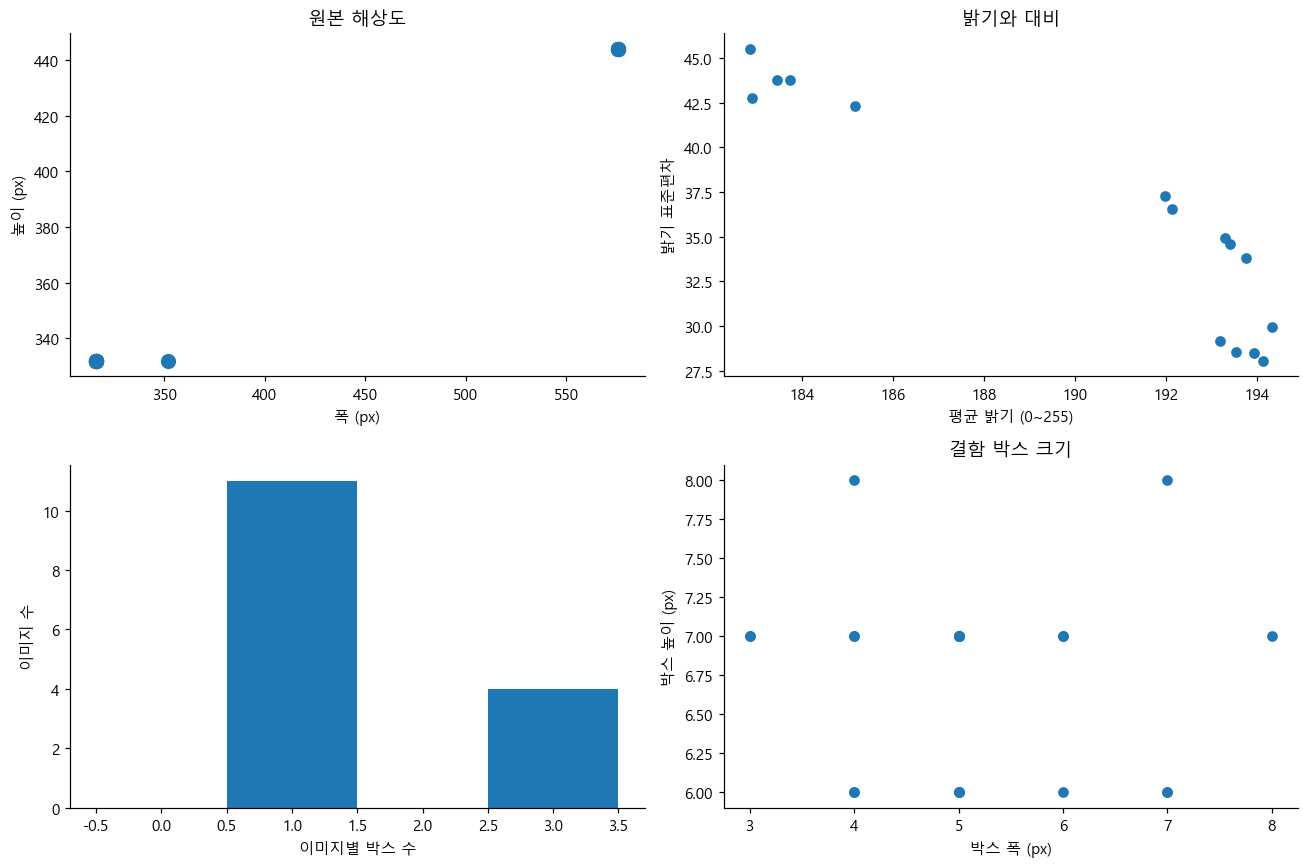

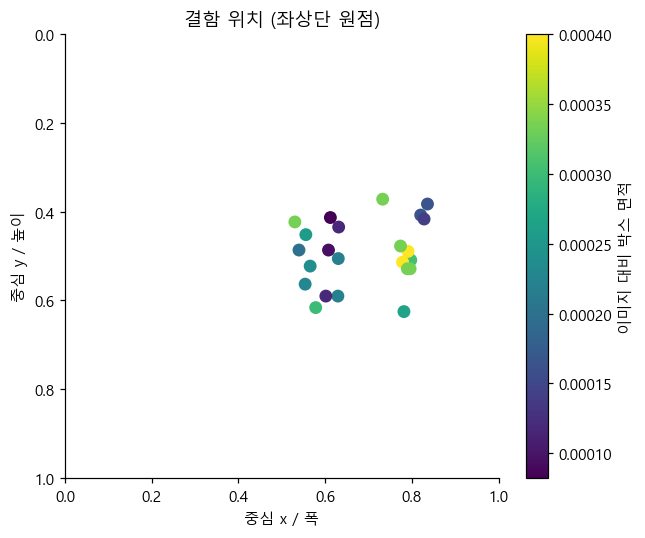

,bw,bh,area_fraction
count,23.000000,23.000000,23.000000
mean,5.130435,6.739130,0.000243
std,1.289973,0.619192,0.000096
min,3.000000,6.000000,0.000082
25%,4.000000,6.000000,0.000164
50%,5.000000,7.000000,0.000240
75%,6.000000,7.000000,0.000334
max,8.000000,8.000000,0.000400


In [4]:
fig,axes=plt.subplots(2,2,figsize=(12,8))
axes[0,0].scatter(unique_images.width,unique_images.height,s=80);axes[0,0].set(xlabel='폭 (px)',ylabel='높이 (px)',title='원본 해상도')
axes[0,1].scatter(unique_images['mean'],unique_images['std']);axes[0,1].set(xlabel='평균 밝기 (0~255)',ylabel='밝기 표준편차',title='밝기와 대비')
axes[1,0].hist(matched.objects,bins=np.arange(0,matched.objects.max()+2)-.5);axes[1,0].set(xlabel='이미지별 박스 수',ylabel='이미지 수')
axes[1,1].scatter(matched_boxes.bw,matched_boxes.bh);axes[1,1].set(xlabel='박스 폭 (px)',ylabel='박스 높이 (px)',title='결함 박스 크기')
plt.tight_layout();plt.show()
fig,ax=plt.subplots(figsize=(6,5));sc=ax.scatter(matched_boxes.cx,matched_boxes.cy,c=matched_boxes.area_fraction,cmap='viridis',s=55)
ax.set(xlim=(0,1),ylim=(1,0),xlabel='중심 x / 폭',ylabel='중심 y / 높이',title='결함 위치 (좌상단 원점)');fig.colorbar(sc,ax=ax,label='이미지 대비 박스 면적');plt.tight_layout();plt.show()
display(matched_boxes[['bw','bh','area_fraction']].describe())

## 4. 이미지 위 주석 확인
15장의 고유 X-ray 이미지를 모두 표시합니다. 작은 결함은 추가 확대 뷰로 확인합니다.

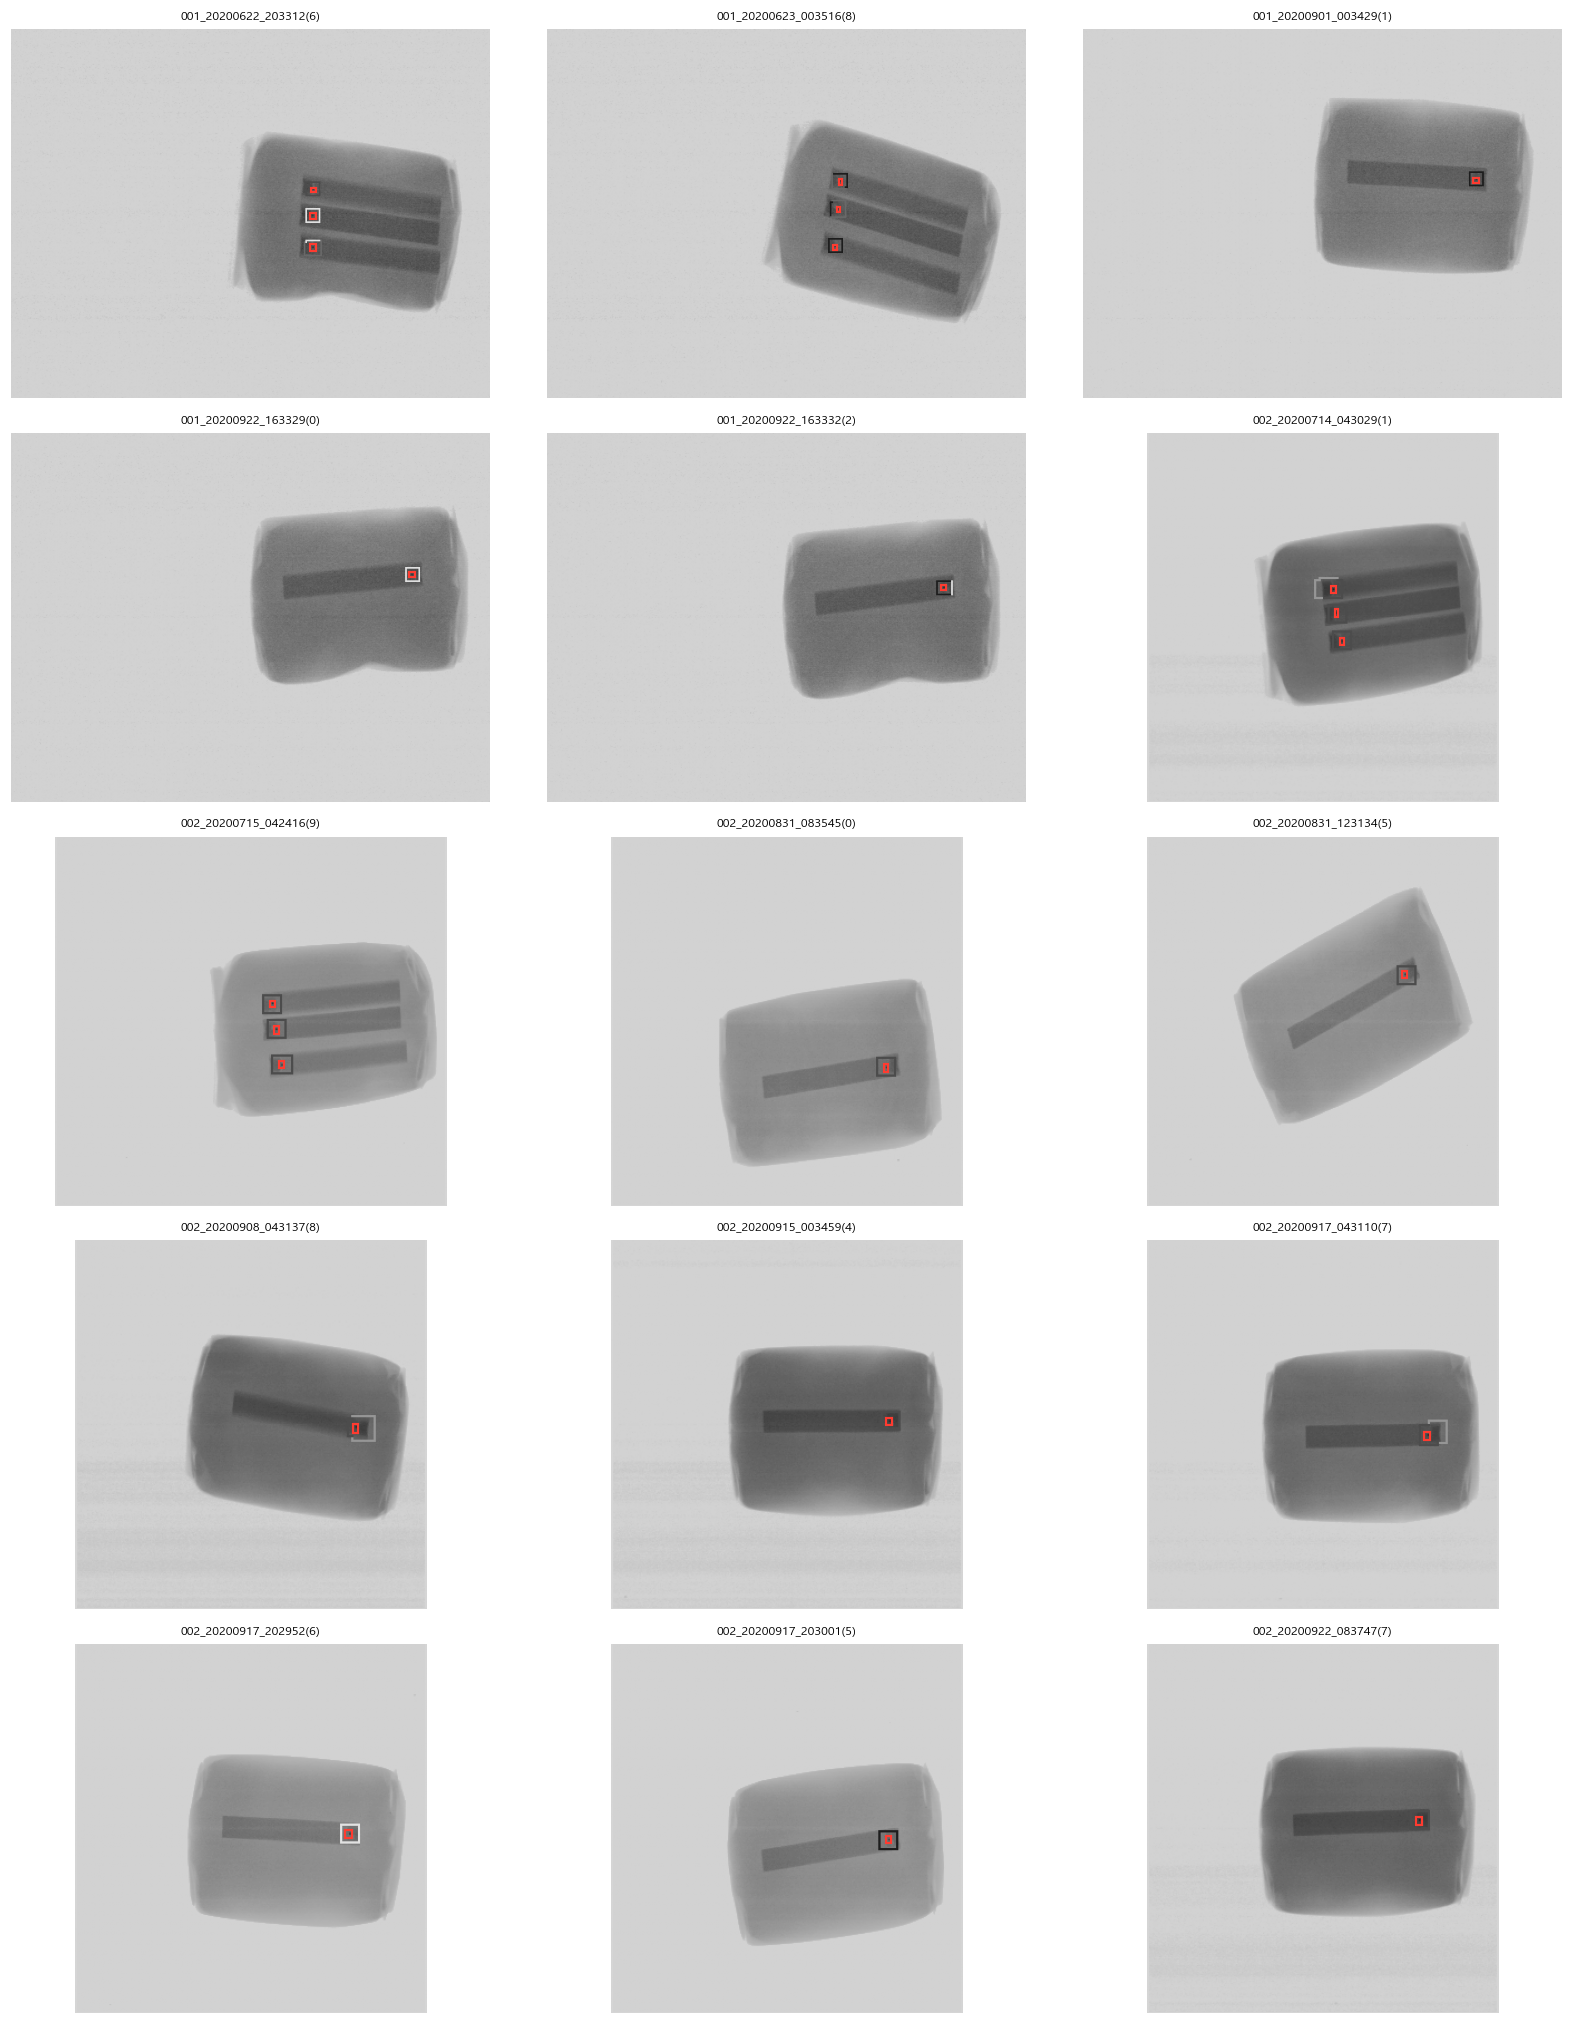

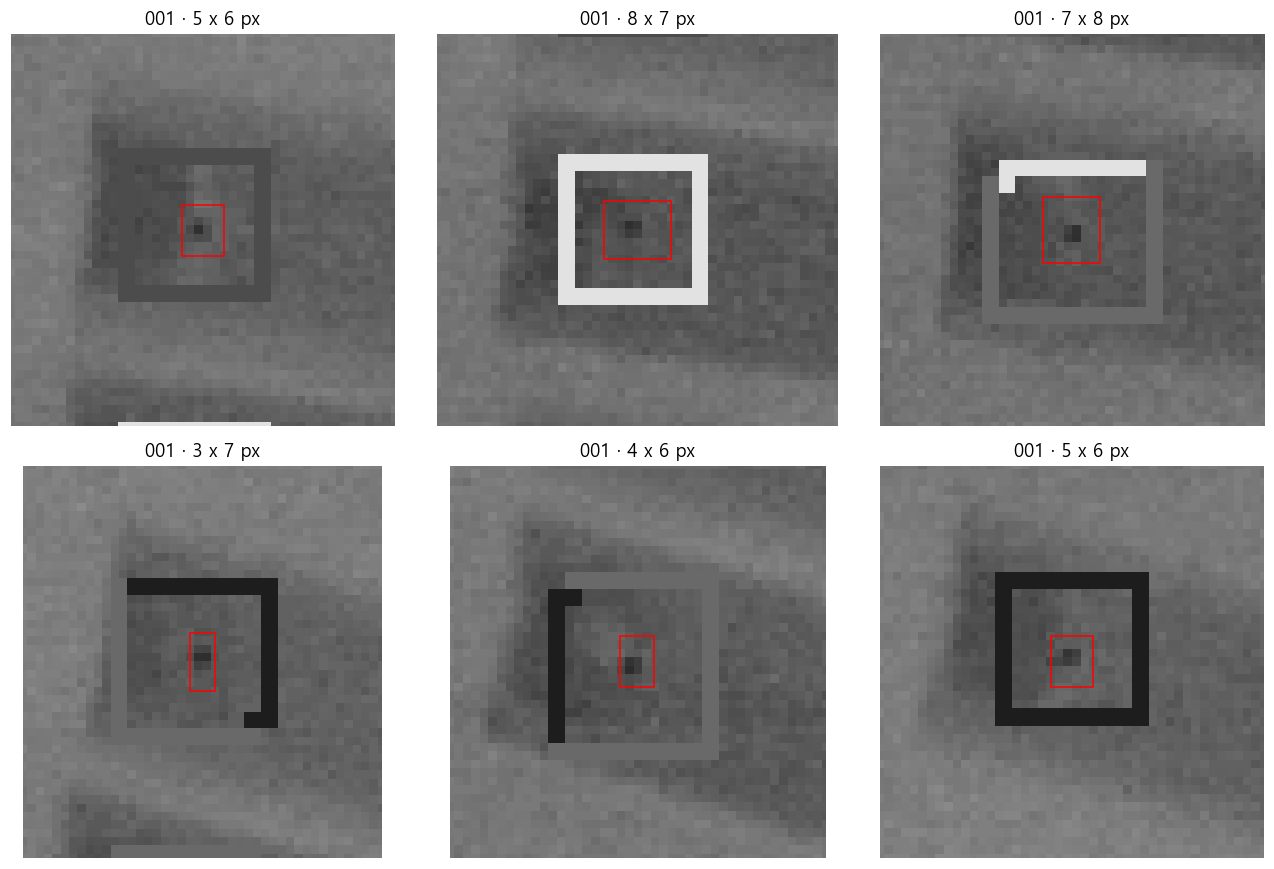

In [5]:
fig,axes=plt.subplots(int(np.ceil(len(unique_images)/3)),3,figsize=(15,3.7*int(np.ceil(len(unique_images)/3))),squeeze=False)
for ax,(_,row) in zip(axes.flat,unique_images.iterrows()):
    with Image.open(row.path) as im:ax.imshow(im.convert('L'),cmap='gray',vmin=0,vmax=255)
    for _,b in matched_boxes[matched_boxes.stem.eq(row.stem)].iterrows():
        ax.add_patch(Rectangle((b.x1,b.y1),b.bw,b.bh,fill=False,edgecolor='#ff3b30',linewidth=1.4))
    ax.set_title(row.stem,fontsize=8);ax.axis('off')
for ax in list(axes.flat)[len(unique_images):]:ax.set_visible(False)
plt.tight_layout();plt.show()
fig,axes=plt.subplots(2,3,figsize=(12,8))
for ax,(_,b) in zip(axes.flat,matched_boxes.head(6).iterrows()):
    row=unique_images[unique_images.stem.eq(b.stem)].iloc[0]
    with Image.open(row.path) as im:ax.imshow(im.convert('L'),cmap='gray',vmin=0,vmax=255)
    ax.add_patch(Rectangle((b.x1,b.y1),b.bw,b.bh,fill=False,edgecolor='red'))
    ax.set_xlim(max(0,b.x1-20),min(row.width,b.x2+20));ax.set_ylim(min(row.height,b.y2+20),max(0,b.y1-20))
    ax.set_title(f'{b.stem[:3]} · {b.bw:.0f} x {b.bh:.0f} px');ax.axis('off')
plt.tight_layout();plt.show()

## 5. YOLO 주석과 기존 분할 목록
YOLO는 class, 중심 x/y, 폭/높이의 정규화 좌표입니다. VOC 변환값과 비교하고 기존 목록의 파일 존재 여부를 별도로 검사합니다. 원본 BMP가 있어도 목록의 JPG 경로가 없으면 기존 스크립트에서는 읽을 수 없습니다.

In [6]:
yolo_dir=next(DATA.rglob('YOLO_darknet')); audits=[]
for _,row in matched.iterrows():
    p=yolo_dir/(row.stem+'.txt')
    vals=np.array([[float(v) for v in line.split()] for line in p.read_text().splitlines() if line.strip()]) if p.exists() else np.empty((0,5))
    b=matched_boxes[matched_boxes.stem.eq(row.stem)]
    expected=np.column_stack([np.zeros(len(b)),b.cx,b.cy,b.bw/row.width_xml,b.bh/row.height_xml])
    ordered=lambda a:a[np.lexsort(a.T[::-1])] if len(a) else a
    equal=vals.shape==expected.shape and np.allclose(ordered(vals),ordered(expected),atol=1e-6)
    audits.append({'stem':row.stem,'yolo_present':p.exists(),'boxes':len(vals),'voc_yolo_match':equal})
display(pd.DataFrame(audits))
split_rows=[]
for name in ['train','test']:
    path=next(DATA.rglob(name+'.txt'))
    for line in path.read_text().splitlines():
        if not line.strip():continue
        rel=Path(line.strip()); stem=rel.stem
        hashes=candidates.loc[candidates.stem.eq(stem),'pixel_hash']
        split_rows.append({'split':name,'entry':line,'stem':stem,'listed_path_exists':(path.parent/rel).exists(),
                           'source_image_available':len(hashes)>0,'pixel_hash':hashes.iloc[0] if len(hashes) else None})
splits=pd.DataFrame(split_rows);display(splits)
display(splits.groupby('split').agg(entries=('entry','size'),listed_files=('listed_path_exists','sum'),available_sources=('source_image_available','sum')))
hash_sets={k:set(g.pixel_hash.dropna()) for k,g in splits.groupby('split')}
print('train/test 픽셀 중복:',len(hash_sets.get('train',set())&hash_sets.get('test',set())))
print('train/test 이름 중복:',len(set(splits.loc[splits.split.eq('train'),'stem'])&set(splits.loc[splits.split.eq('test'),'stem'])))

,stem,yolo_present,boxes,voc_yolo_match
0,001_20200622_203312(6),True,3,True
1,001_20200623_003516(8),True,3,True
2,001_20200901_003429(1),True,1,True
3,001_20200922_163329(0),True,1,True
4,001_20200922_163332(2),True,1,True
5,002_20200714_043029(1),True,3,True
6,002_20200715_042416(9),True,3,True
7,002_20200831_083545(0),True,1,True
8,002_20200831_123134(5),True,1,True
9,002_20200908_043137(8),True,1,True


,split,entry,stem,listed_path_exists,source_image_available,pixel_hash
0,train,images/001_20200901_003429(1).jpg,001_20200901_003429(1),True,True,9815d3ba338c89c867325353db6a71922a650fd5b43aee...
1,train,images/001_20200922_163329(0).jpg,001_20200922_163329(0),True,True,217ad002578667d1094bc8738dd308c98872529f61fdd9...
2,train,images/001_20200922_163332(2).jpg,001_20200922_163332(2),False,True,cdcd2ce5c2dc23c289354bc45f3f48f5e3b42d4b18a76b...
3,train,images/002_20200714_043029(1).jpg,002_20200714_043029(1),False,True,8ef6900d12c107cb2bb52f0c501170cf4c95894584dc57...
4,train,images/002_20200715_042416(9).jpg,002_20200715_042416(9),False,True,0b17e26d00bdb6e327b242250cd6837efc6341d52bc73c...
5,train,images/002_20200831_083545(0).jpg,002_20200831_083545(0),False,True,15e4657c12c3223608d95f6865090a2fc52ab2d43899a5...
6,train,images/002_20200831_123134(5).jpg,002_20200831_123134(5),False,True,ef82e0ca3366c3185b9f3770c5996be77e96531703cb2c...
7,train,images/002_20200908_043137(8).jpg,002_20200908_043137(8),False,True,7e1be50e4f5fd7438eff259df3a6dc359767976e8e4e64...
8,train,images/002_20200917_043110(7).jpg,002_20200917_043110(7),False,True,98b881eb4e6394cecc7624522f867a121882da3d297a16...
9,train,images/002_20200917_202952(6).jpg,002_20200917_202952(6),False,True,209f2414638a357b64ec6c894b3efafd454e0745eabec6...


,entries,listed_files,available_sources
split,,,
test,3,2,3
train,12,2,12


train/test 픽셀 중복: 0
train/test 이름 중복: 0


## 6. 주제 선정 해석
- 이미지 확장자를 가진 코드·설명 파일과 도구 예제 XML이 섞여 있으므로 전체 파일 수를 학습 표본 수로 사용하면 안 됩니다.
- 현재 고유 X-ray 원본은 15장입니다. 수십만 픽셀이나 여러 박스가 있어도 독립 이미지 15장이라는 한계가 사라지지 않습니다.
- XML 833개 중 X-ray 이름 패턴은 35개이며, 15개만 원본과 연결되고 20개는 이미지가 없습니다. 연결된 결함 박스는 23개이고 폭 3~8px, 높이 6~8px입니다.
- 기존 train/test 목록 15개 경로 중 4개만 그대로 존재합니다. BMP 원본은 15장 모두 있으므로 후속 학습 시 경로/포맷 정리가 필요합니다.
- 결함 박스가 매우 작아 원본 해상도 보존과 확대/타일링 실험이 필요합니다. 타일을 나눈다면 원본 이미지 단위로 학습·검증을 분리합니다.
- 확대 뷰의 일부 원본에는 빨간 EDA 박스 외에 두꺼운 밝은색/어두운색 사각 표시가 보입니다. 검사 단계에서 추가한 표시인지 확인하고, 라벨 단서가 이미지에 포함된 경우 표시 없는 원본을 확보해야 합니다.
- 이미지가 없는 X-ray 주석의 원본, 추가 검사 이미지, 정상 무결함 이미지 및 촬영 로트 정보를 확보하는 것이 우선입니다.
- 동봉된 결과 그림과 학습 로그는 재현한 모델 성능이 아닙니다. 본 EDA는 데이터 가용성·주석 상태만 검증합니다.